<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab2/blob/main/oftutorial/OscilloscopeTutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visuals for Oscilloscope Fundamentals

# Sine Wave

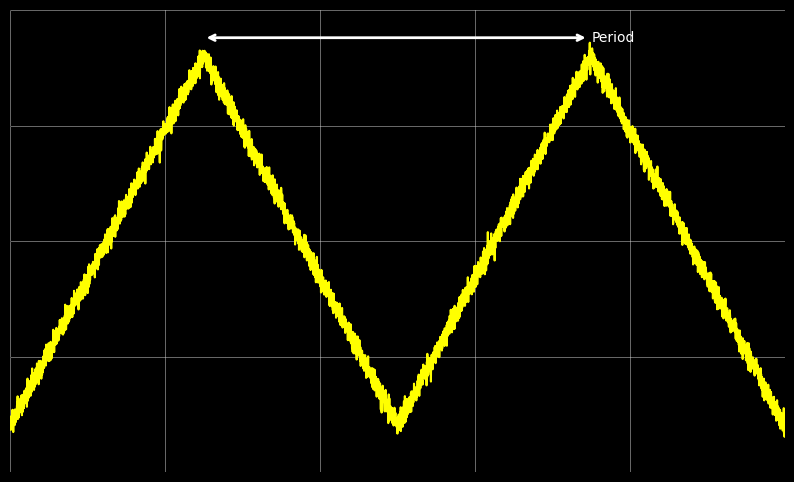

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate triangle wave data
x = np.linspace(0, 4 * np.pi, 5000) # Two full cycles

P = 2 * np.pi # Period of the triangle wave
t_in_period = x % P
triangle_base_wave = np.where(t_in_period < P/2,
                              (2 * t_in_period / P * 2) - 1, # Ramp up from -1 to 1
                              (2 * (P - t_in_period) / P * 2) - 1) # Ramp down from 1 to -1
y = 0.8 * np.round(128 * triangle_base_wave)
A = 128 * 0.8 # peak amplitude value

# Add a small amount of random noise to the wave
# The scale of the noise can be adjusted (e.g., 0.1 for 10% of amplitude)
noise = np.random.normal(0, 3, y.shape) # Mean 0, standard deviation 1
y_noisy = y + noise

# 2. Create a figure and an axes object
fig, ax = plt.subplots(figsize=(10, 6)) # Adjust figsize for better aspect ratio

# 3. Set dark background for the axes and the figure
ax.set_facecolor('black')
fig.patch.set_facecolor('black')

# 4. Plot the wave
ax.plot(x, y_noisy, color='yellow', linewidth=1.5)

# 5. Remove axes (spines, ticks, and labels)
ax.set_xticks([]) # Remove x-tick marks
ax.set_yticks([]) # Remove y-tick marks
ax.set_xticklabels([]) # Remove x-tick labels
ax.set_yticklabels([]) # Remove y-tick labels

# Remove the box/spines around the plot
for spine in ax.spines.values():
    spine.set_visible(False)

# 6. Configure grid like DSO: 8 cells vertically and 10 cells horizontally
# Define plot limits to control the grid extent
x_min, x_max = 0, 4 * np.pi
y_min, y_max = -128, 128 # Extend slightly beyond wave amplitude

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Calculate major tick locations for the grid
# 10 horizontal cells for x-axis
x_major_interval = (x_max - x_min) / 5
ax.set_xticks(np.arange(x_min, x_max + x_major_interval / 2, x_major_interval))

# 8 vertical cells for y-axis
y_major_interval = (y_max - y_min) / 4
ax.set_yticks(np.arange(y_min, y_max + y_major_interval / 2, y_major_interval))

# Apply lightgray grid
ax.grid(True, which='major', color='lightgray', linestyle='-', linewidth=0.5, alpha=0.7)

COLOR_ARROW = 'white'
# Draw Peak-to-Peak line and annotate
x1 = np.pi
plt.annotate(
    "Period",          # Your text label
    color=COLOR_ARROW,
    xy=(x1, A+A/10),       # Arrow tip 1
    xytext=(x1+2*np.pi, A+A/10),   # Arrow tip 2
    ha="left",        # Placed to the left of the arrow line
    va="center",       # Vertically centered
    xycoords="data",
    textcoords="data",
    rotation_mode="anchor",  # Keeps alignment properties intact after rotation
    # xytext padding to push text away from the line
    arrowprops=dict(arrowstyle="<->", color=COLOR_ARROW, lw=2)
)

# Display the plot
plt.savefig('triangle_wave.png', dpi=300, bbox_inches='tight')
plt.show()

# Sine wave - amplitudes

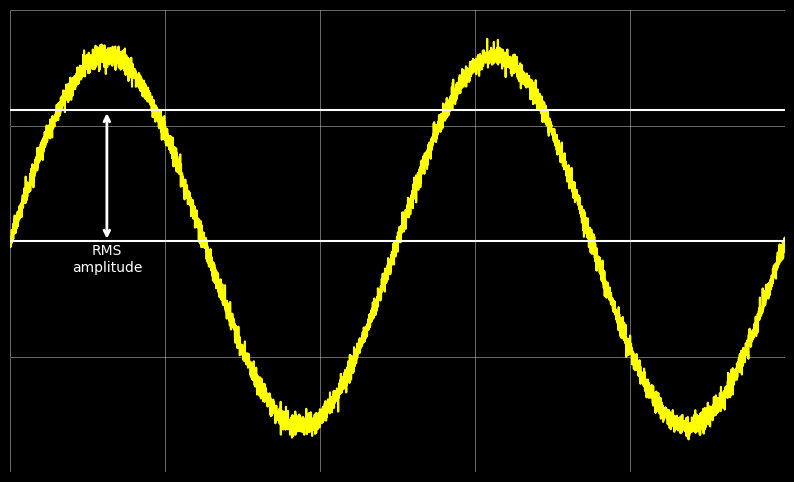

In [2]:
# 1. Generate sine wave data
x = np.linspace(0, 4 * np.pi, 5000) # Two full cycles
y = 0.8 * np.round(128*np.sin(x))
A = 128 * 0.8 # peak amplitude value

# Add a small amount of random noise to the sine wave
# The scale of the noise can be adjusted (e.g., 0.1 for 10% of amplitude)
noise = np.random.normal(0, 3, y.shape) # Mean 0, standard deviation 1
y_noisy = y + noise

# 2. Create a figure and an axes object
fig, ax = plt.subplots(figsize=(10, 6)) # Adjust figsize for better aspect ratio

# 3. Set dark background for the axes and the figure
ax.set_facecolor('black')
fig.patch.set_facecolor('black')

# 4. Plot the sine wave
ax.plot(x, y_noisy, color='yellow', linewidth=1.5)

# 5. Remove axes (spines, ticks, and labels)
ax.set_xticks([]) # Remove x-tick marks
ax.set_yticks([]) # Remove y-tick marks
ax.set_xticklabels([]) # Remove x-tick labels
ax.set_yticklabels([]) # Remove y-tick labels

# Remove the box/spines around the plot
for spine in ax.spines.values():
    spine.set_visible(False)

# 6. Configure grid like DSO: 8 cells vertically and 10 cells horizontally
# Define plot limits to control the grid extent
x_min, x_max = 0, 4 * np.pi
y_min, y_max = -128, 128 # Extend slightly beyond sine wave amplitude

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Calculate major tick locations for the grid
# 10 horizontal cells for x-axis
x_major_interval = (x_max - x_min) / 5
ax.set_xticks(np.arange(x_min, x_max + x_major_interval / 2, x_major_interval))

# 8 vertical cells for y-axis
y_major_interval = (y_max - y_min) / 4
ax.set_yticks(np.arange(y_min, y_max + y_major_interval / 2, y_major_interval))

# Apply lightgray grid
ax.grid(True, which='major', color='lightgray', linestyle='-', linewidth=0.5, alpha=0.7)

COLOR_ARROW = 'white'
# Draw Peak-to-Peak line and annotate
x1 = np.pi/2
plt.annotate(
    "RMS\namplitude",          # Your text label
    color=COLOR_ARROW,
    xy=(x1, A/np.sqrt(2)),       # Arrow tip 1
    xytext=(x1, -A/10),   # Arrow tip 2
    ha="center",        # Placed to the left of the arrow line
    va="center",       # Vertically centered
    xycoords="data",
    textcoords="data",
    rotation_mode="anchor",  # Keeps alignment properties intact after rotation
    # xytext padding to push text away from the line
    arrowprops=dict(arrowstyle="<->", color=COLOR_ARROW, lw=2)
)

x1 = 3* np.pi / 2
#plt.annotate(
#    "RMS\namplitude",          # Your text label
#    color=COLOR_ARROW,
#    xy=(x1, A/np.sqrt(2)),       # Arrow tip 1
#    xytext=(x1, -A/10),   # Arrow tip 2
#    ha="center",        # Placed to the left of the arrow line
#    va="center",       # Vertically centered
#    xycoords="data",
#    textcoords="data",
#    rotation_mode="anchor",  # Keeps alignment properties intact after rotation
#    # xytext padding to push text away from the line
#    arrowprops=dict(arrowstyle="<->", color=COLOR_ARROW, lw=2)
#)

x1 = 5* np.pi / 2
#plt.annotate(
#    "Peak-to-peak\namplitude",          # Your text label
##    color=COLOR_ARROW,
#    xy=(x1, A),       # Arrow tip 1
#    xytext=(x1, -A -A/10),   # Arrow tip 2
#    ha="center",        # Placed to the left of the arrow line
#    va="center",       # Vertically centered
#    xycoords="data",
#    textcoords="data",
#    rotation_mode="anchor",  # Keeps alignment properties intact after rotation
#    # xytext padding to push text away from the line
#    arrowprops=dict(arrowstyle="<->", color=COLOR_ARROW, lw=2)
#)
plt.axhline(y=0, color='white', linestyle='-')
plt.axhline(y=A/np.sqrt(2), color='white', linestyle='-')

# Display the plot
plt.savefig('sine_wave_RMS_amplitude.png', dpi=300, bbox_inches='tight')
plt.show()

# Sine - period

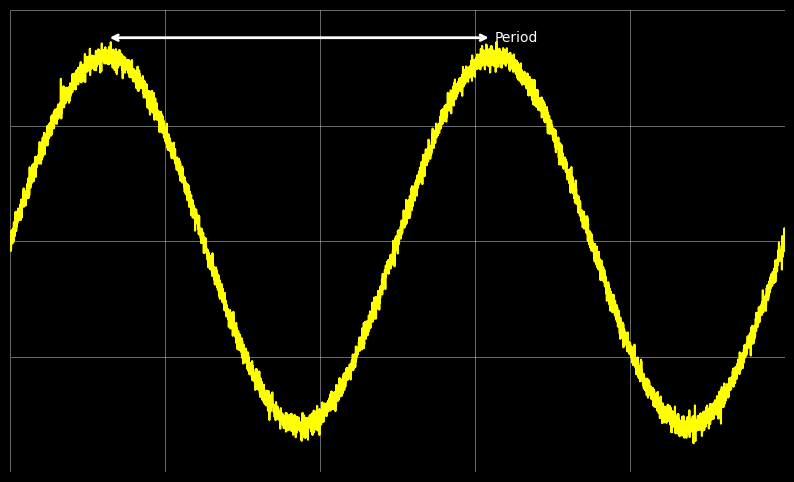

In [3]:
# 1. Generate sine wave data
x = np.linspace(0, 4 * np.pi, 5000) # Two full cycles
y = 0.8 * np.round(128*np.sin(x))
A = 128 * 0.8 # peak amplitude value

# Add a small amount of random noise to the sine wave
# The scale of the noise can be adjusted (e.g., 0.1 for 10% of amplitude)
noise = np.random.normal(0, 3, y.shape) # Mean 0, standard deviation 1
y_noisy = y + noise

# 2. Create a figure and an axes object
fig, ax = plt.subplots(figsize=(10, 6)) # Adjust figsize for better aspect ratio

# 3. Set dark background for the axes and the figure
ax.set_facecolor('black')
fig.patch.set_facecolor('black')

# 4. Plot the sine wave
ax.plot(x, y_noisy, color='yellow', linewidth=1.5)

# 5. Remove axes (spines, ticks, and labels)
ax.set_xticks([]) # Remove x-tick marks
ax.set_yticks([]) # Remove y-tick marks
ax.set_xticklabels([]) # Remove x-tick labels
ax.set_yticklabels([]) # Remove y-tick labels

# Remove the box/spines around the plot
for spine in ax.spines.values():
    spine.set_visible(False)

# 6. Configure grid like DSO: 8 cells vertically and 10 cells horizontally
# Define plot limits to control the grid extent
x_min, x_max = 0, 4 * np.pi
y_min, y_max = -128, 128 # Extend slightly beyond sine wave amplitude

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Calculate major tick locations for the grid
# 10 horizontal cells for x-axis
x_major_interval = (x_max - x_min) / 5
ax.set_xticks(np.arange(x_min, x_max + x_major_interval / 2, x_major_interval))

# 8 vertical cells for y-axis
y_major_interval = (y_max - y_min) / 4
ax.set_yticks(np.arange(y_min, y_max + y_major_interval / 2, y_major_interval))

# Apply lightgray grid
ax.grid(True, which='major', color='lightgray', linestyle='-', linewidth=0.5, alpha=0.7)

COLOR_ARROW = 'white'
# Draw Peak-to-Peak line and annotate
x1 = np.pi/2
plt.annotate(
    "Period",          # Your text label
    color=COLOR_ARROW,
    xy=(x1, A+A/10),       # Arrow tip 1
    xytext=(x1+2*np.pi, A+A/10),   # Arrow tip 2
    ha="left",        # Placed to the left of the arrow line
    va="center",       # Vertically centered
    xycoords="data",
    textcoords="data",
    rotation_mode="anchor",  # Keeps alignment properties intact after rotation
    # xytext padding to push text away from the line
    arrowprops=dict(arrowstyle="<->", color=COLOR_ARROW, lw=2)
)




# Display the plot
plt.savefig('sine_wave_period.png', dpi=300, bbox_inches='tight')
plt.show()

#Lissajou figures

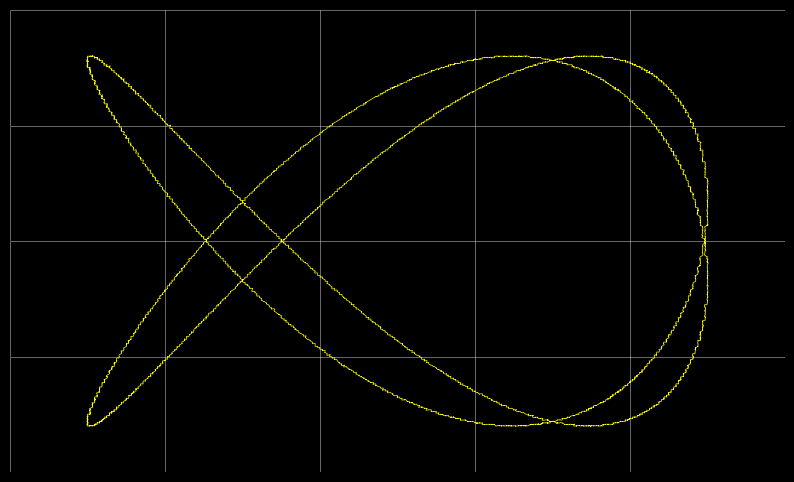

In [7]:
# 1. Generate sine wave data
x = np.linspace(0, 4 * np.pi, 5000) # Two full cycles
y1 = 0.8 * np.round(128*np.sin(x))
y2 = 0.8 * np.round(128*np.sin(1.5*x + 1))
A = 128 * 0.8 # peak amplitude value

# Add a small amount of random noise to the sine wave
# The scale of the noise can be adjusted (e.g., 0.1 for 10% of amplitude)
noise = np.random.normal(0, 0.1, y.shape) # Mean 0, standard deviation 1
y1_noisy = y1 + noise
y2_noisy = y2 + noise

# 2. Create a figure and an axes object
fig, ax = plt.subplots(figsize=(10, 6)) # Adjust figsize for better aspect ratio

# 3. Set dark background for the axes and the figure
ax.set_facecolor('black')
fig.patch.set_facecolor('black')

# 4. Plot the sine wave
ax.plot(y1_noisy, y2_noisy, color='yellow', linewidth=.5)

# 5. Remove axes (spines, ticks, and labels)
ax.set_xticks([]) # Remove x-tick marks
ax.set_yticks([]) # Remove y-tick marks
ax.set_xticklabels([]) # Remove x-tick labels
ax.set_yticklabels([]) # Remove y-tick labels

# Remove the box/spines around the plot
for spine in ax.spines.values():
    spine.set_visible(False)

# 6. Configure grid like DSO: 8 cells vertically and 10 cells horizontally
# Define plot limits to control the grid extent
y_min, y_max = -128, 128 # Extend slightly beyond sine wave amplitude

#ax.set_xlim(x_min, x_max)
#ax.set_ylim(y_min, y_max)

# Calculate major tick locations for the grid

# 8 vertical cells for y-axis
y1_major_interval = (y_max - y_min) / 5
ax.set_xticks(np.arange(y_min, y_max + y_major_interval / 2, y1_major_interval))

y2_major_interval = (y_max - y_min) / 4
ax.set_yticks(np.arange(y_min, y_max + y_major_interval / 2, y2_major_interval))

# Apply lightgray grid
ax.grid(True, which='major', color='lightgray', linestyle='-', linewidth=0.5, alpha=0.7)





# Display the plot
plt.savefig('lissajou15.png', dpi=300, bbox_inches='tight')
plt.show()